In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("./asl_landmarks_final.csv")

In [3]:
df.head()

,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.302490,0.495331,-4.277665e-07,0.401974,0.430925,-0.032561,0.477837,0.337875,-0.043061,0.478437,...,0.213375,0.267955,-0.066850,0.231382,0.334585,-0.057832,0.251276,0.383591,-0.037033,A
1,0.765451,0.343823,-3.595415e-07,0.847147,0.297660,-0.020126,0.900564,0.220337,-0.024878,0.908948,...,0.702640,0.151641,-0.048588,0.717729,0.205214,-0.042068,0.725503,0.254414,-0.026609,A
2,0.354618,0.851986,-5.631421e-07,0.456605,0.802520,-0.032938,0.531164,0.713107,-0.044213,0.533721,...,0.292963,0.614532,-0.061759,0.306808,0.681638,-0.048837,0.310394,0.736855,-0.026207,A
3,0.508807,0.903747,-4.856587e-07,0.601312,0.872814,-0.048935,0.698089,0.763118,-0.064034,0.720130,...,0.421785,0.662791,-0.088294,0.430163,0.749342,-0.076930,0.433897,0.807848,-0.050230,A
4,0.424728,0.795478,-5.605922e-07,0.571597,0.744283,-0.063864,0.700230,0.593906,-0.080447,0.721148,...,0.309938,0.437413,-0.105951,0.333689,0.541939,-0.089638,0.340167,0.628113,-0.053260,A


In [4]:
df.shape

(2203, 64)

In [5]:
df.columns

Index(['x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3',
       'x4', 'y4', 'z4', 'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7',
       'x8', 'y8', 'z8', 'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11',
       'z11', 'x12', 'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14',
       'x15', 'y15', 'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18',
       'y18', 'z18', 'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2203 entries, 0 to 2202
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      2203 non-null   float64
 1   y0      2203 non-null   float64
 2   z0      2203 non-null   float64
 3   x1      2203 non-null   float64
 4   y1      2203 non-null   float64
 5   z1      2203 non-null   float64
 6   x2      2203 non-null   float64
 7   y2      2203 non-null   float64
 8   z2      2203 non-null   float64
 9   x3      2203 non-null   float64
 10  y3      2203 non-null   float64
 11  z3      2203 non-null   float64
 12  x4      2203 non-null   float64
 13  y4      2203 non-null   float64
 14  z4      2203 non-null   float64
 15  x5      2203 non-null   float64
 16  y5      2203 non-null   float64
 17  z5      2203 non-null   float64
 18  x6      2203 non-null   float64
 19  y6      2203 non-null   float64
 20  z6      2203 non-null   float64
 21  x7      2203 non-null   float64
 22  

In [7]:
df.isna().sum()

x0       0
y0       0
z0       0
x1       0
y1       0
        ..
z19      0
x20      0
y20      0
z20      0
label    0
Length: 64, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Perform Univariate Analysis Bivariate Analysis Multivariate Analysis


### Count Plot

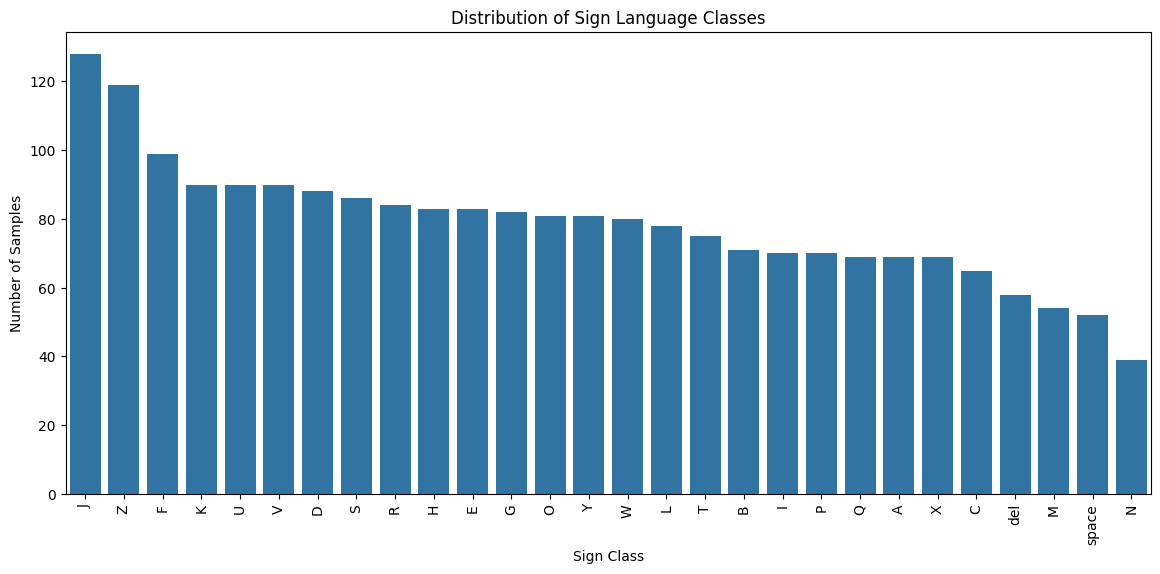

In [9]:
target="label"
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x=target,
    order=df[target].value_counts().index
)

plt.title("Distribution of Sign Language Classes")
plt.xlabel("Sign Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.show()

### Histogram

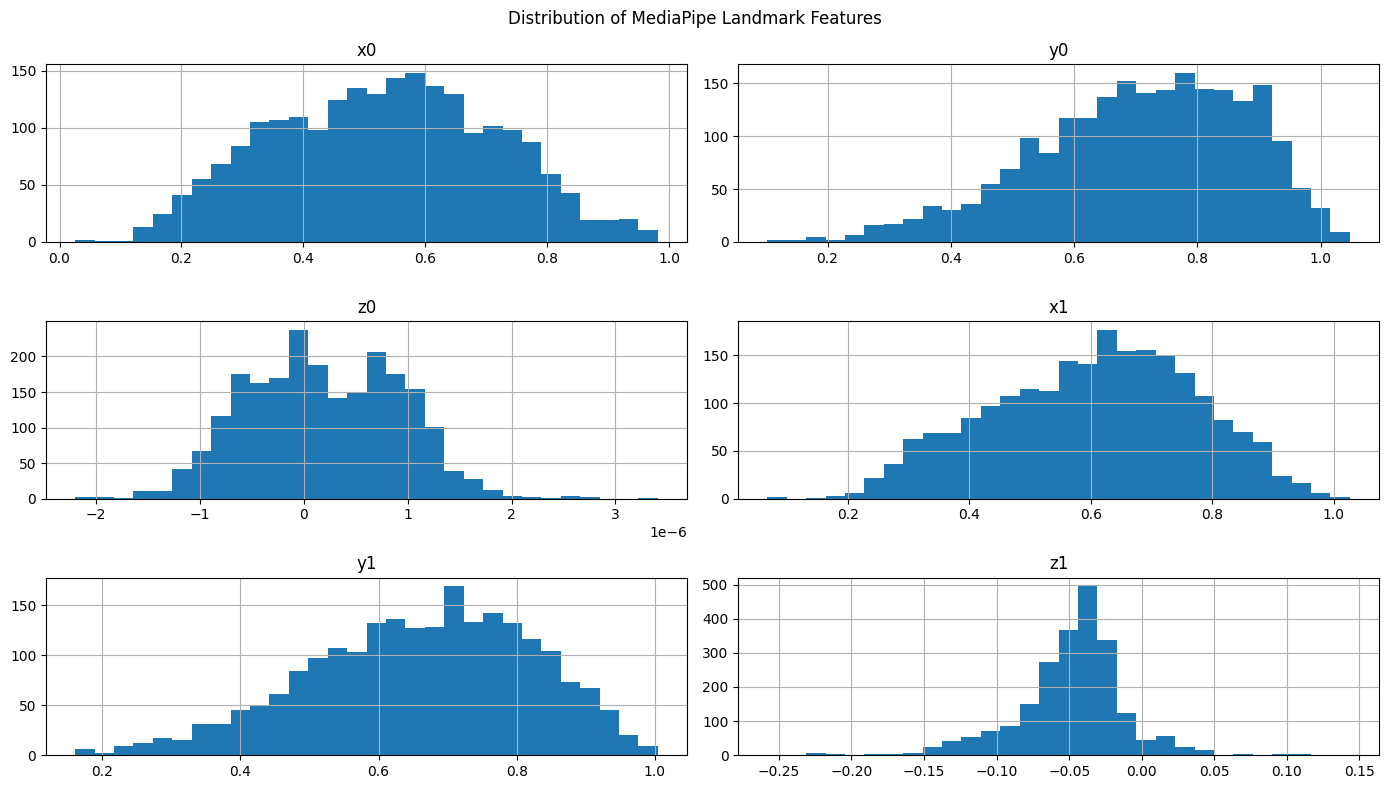

In [16]:
selected_features = numeric_cols[:6]

df[selected_features].hist(
    figsize=(14, 8),
    bins=30
)

plt.suptitle("Distribution of MediaPipe Landmark Features")
plt.tight_layout()
plt.show()

### Pie Plot

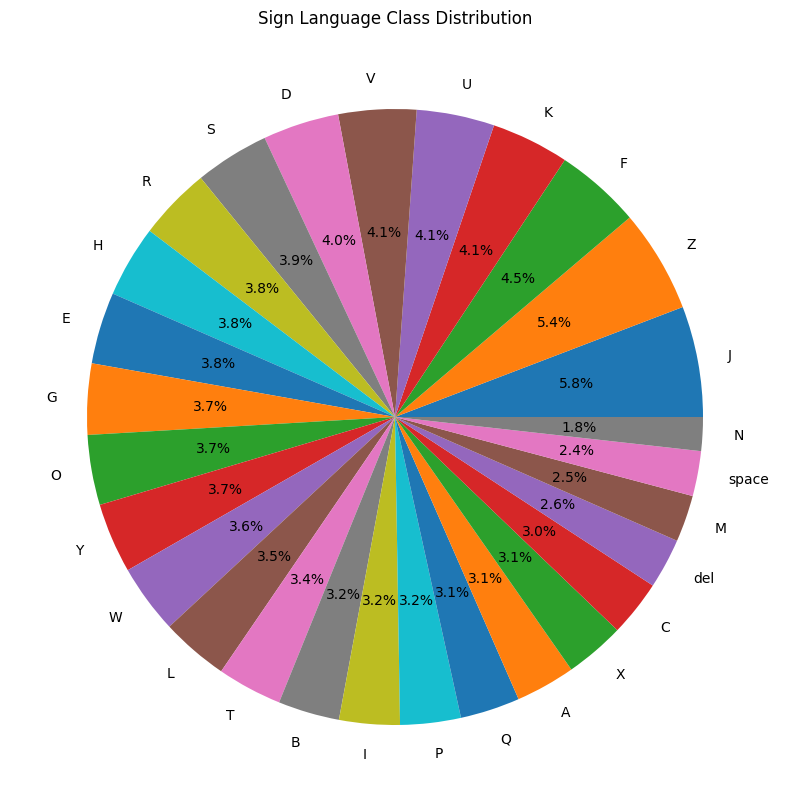

In [10]:
plt.figure(figsize=(10, 10))

df[target].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sign Language Class Distribution")
plt.ylabel("")
plt.show()

### Univariate Analysis
`Observations:` 
- The 63 MediaPipe features represent the X, Y and Z coordinates of the 21 hand landmarks.
- The X and Y coordinates generally represent normalized spatial positions of the hand landmarks.
- The Z coordinates have values close to zero in this dataset.
  
`Insights:`
- The features contain spatial information about hand shape and position.
- Different hand signs should produce different configurations of these landmark coordinates.
  
`Recommendations:`
- Inspect the distributions of representative X, Y and Z features using histograms and box plots.
- Standardize/scale the numerical features before ANN training.

## Bivariate Analysis

### Landmark feature vs sign class

In [11]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

In [12]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
x0,2203.0,5.317420e-01,1.815464e-01,0.025746,3.921006e-01,5.369031e-01,6.631193e-01,0.981659
y0,2203.0,7.068540e-01,1.699654e-01,0.102257,5.969203e-01,7.244462e-01,8.391392e-01,1.047384
z0,2203.0,1.897659e-07,7.315738e-07,-0.000002,-3.753864e-07,1.341073e-07,7.577445e-07,0.000003
x1,2203.0,6.032712e-01,1.670443e-01,0.067390,4.807453e-01,6.171776e-01,7.270154e-01,1.026997
y1,2203.0,6.610889e-01,1.608105e-01,0.161113,5.508329e-01,6.723639e-01,7.830504e-01,1.004310
...,...,...,...,...,...,...,...,...
y19,2203.0,5.083384e-01,1.751336e-01,0.032666,3.743517e-01,5.128514e-01,6.489725e-01,0.966529
z19,2203.0,-7.701550e-02,5.706392e-02,-0.489636,-1.005310e-01,-6.921298e-02,-4.309447e-02,0.094707
x20,2203.0,4.501592e-01,1.868657e-01,-0.034267,2.971118e-01,4.428129e-01,5.893703e-01,0.981188
y20,2203.0,5.269454e-01,1.924279e-01,0.023360,3.728256e-01,5.359783e-01,6.838763e-01,0.987658


### Box Plot

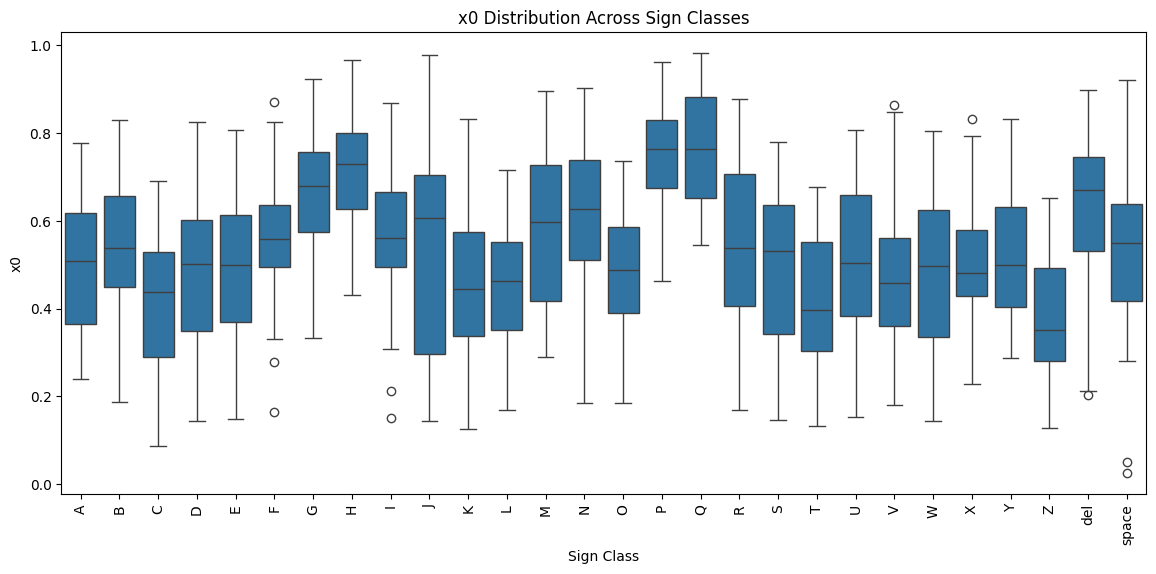

In [13]:
feature = numeric_cols[0]

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x=target,
    y=feature
)

plt.title(f"{feature} Distribution Across Sign Classes")
plt.xlabel("Sign Class")
plt.ylabel(feature)
plt.xticks(rotation=90)

plt.show()

### 6. Feature vs Feature Scatter Plot

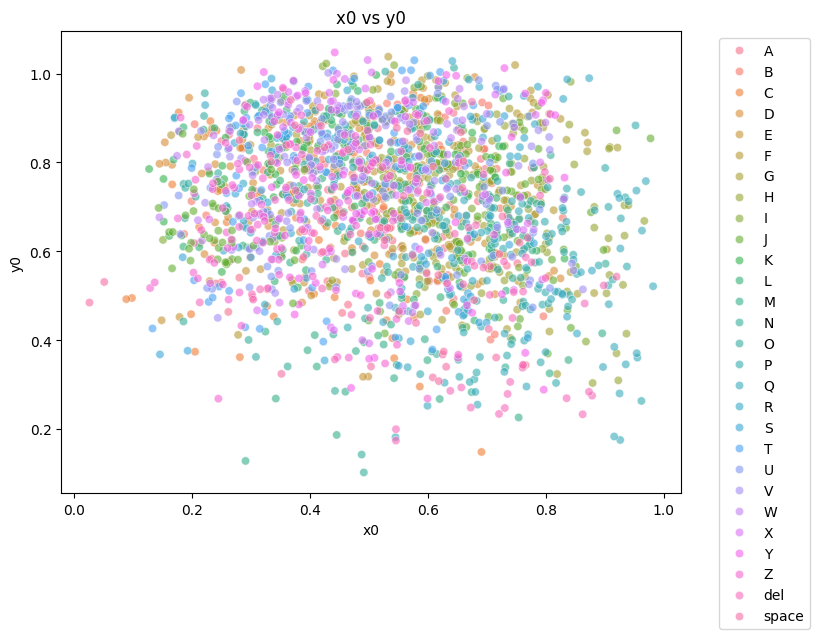

In [14]:
x_feature = numeric_cols[0]
y_feature = numeric_cols[1]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x_feature,
    y=y_feature,
    hue=target,
    alpha=0.6
)

plt.title(f"{x_feature} vs {y_feature}")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

### Bivariate Analysis
`Landmark Feature vs Label`

`Observation`

- The distributions of individual landmark coordinates vary across sign classes.
- Some landmark coordinates show clearer differences between classes than others.

`Insight`

- Individual landmarks may contribute differently to distinguishing hand signs.
- However, a single coordinate is unlikely to be sufficient to identify a sign.

`Recommendation`

- Use all relevant MediaPipe landmark features initially.
- Allow the ANN to learn the combined spatial relationships between landmarks.

`Feature vs Feature`

- Your dataset also has very strong correlations between some landmark coordinates. For example, some feature pairs have correlations above 0.98.

`Observation`

- Several MediaPipe features are highly correlated.

`Insight`

- This is expected because neighboring hand landmarks move together when the hand changes position or shape.
- Therefore, some information in the 63 features is redundant.

`Recommendation`

- Retain the features initially because ANN can learn from the complete landmark representation.
- Feature reduction can be considered later if it improves training speed without reducing classification performance.

### MULTIVARIATE ANALYSIS

### Correlation map

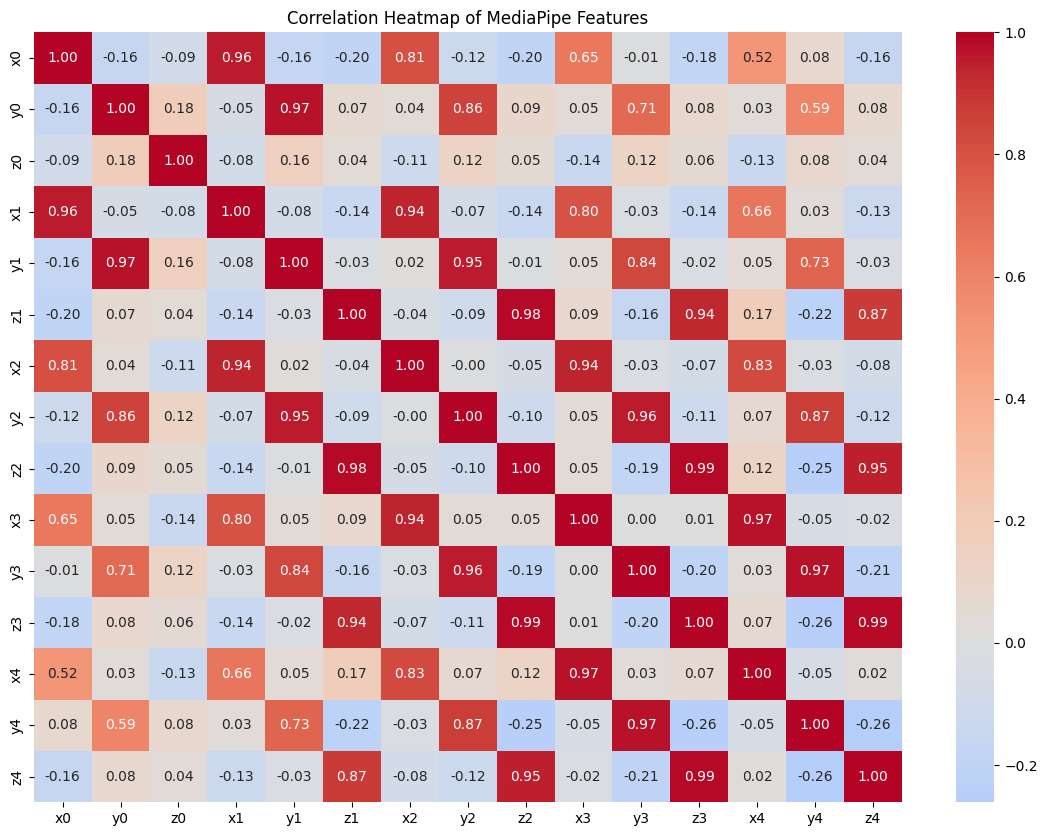

In [15]:
corr_features = numeric_cols[:15]

plt.figure(figsize=(14, 10))

corr_matrix = df[corr_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of MediaPipe Features")
plt.show()

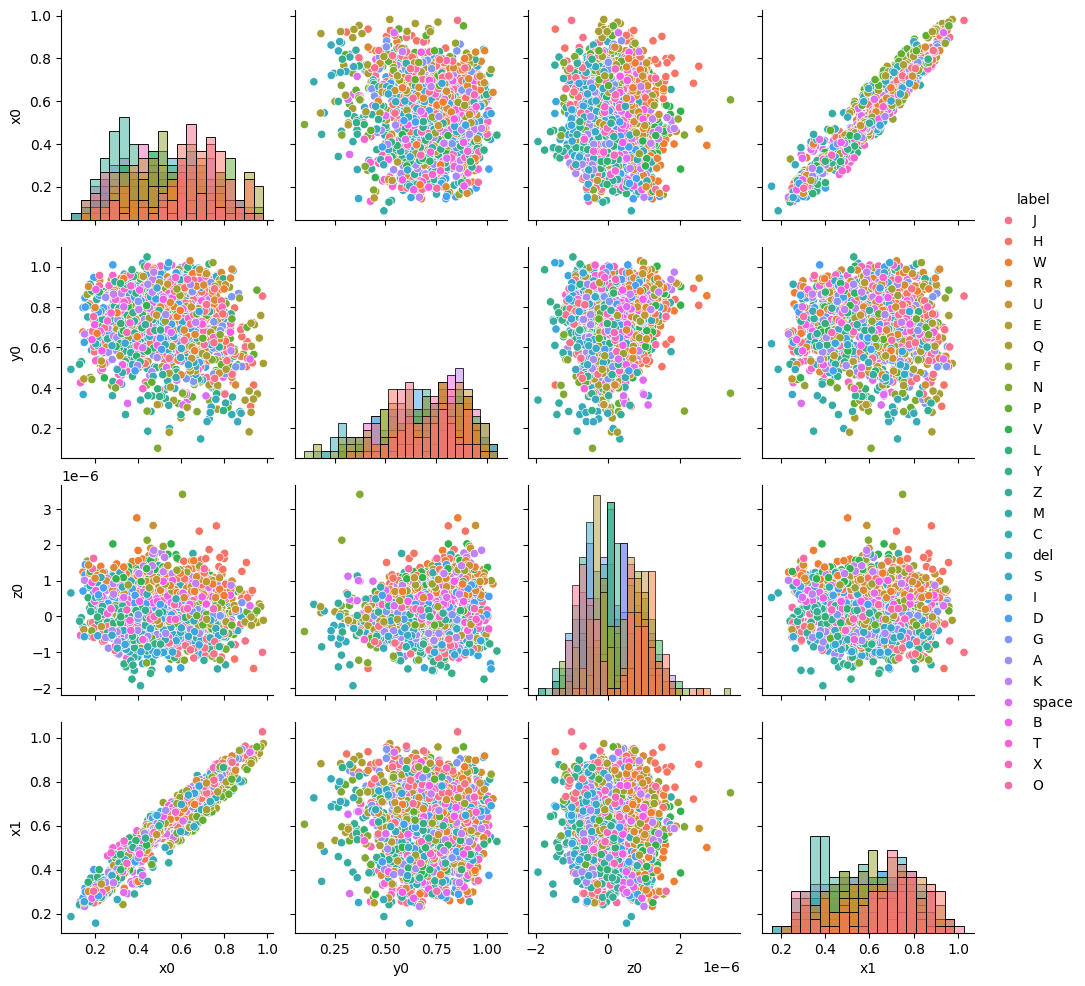

In [17]:
pair_features = numeric_cols[:4] + [target]

pairplot_df = df[pair_features].sample(
    min(1500, len(df)),
    random_state=42
)

sns.pairplot(
    pairplot_df,
    hue=target,
    diag_kind="hist"
)

plt.show()

### Multivariate Analysis
`Correlation Heatmap`

`Observation`

- The correlation matrix shows strong relationships among several MediaPipe landmark coordinates.
- Some feature pairs have correlation values close to 1.

`Insight`

- Hand landmarks are spatially related, so movement of one landmark is often associated with movement of neighboring landmarks.
- The complete hand configuration is more informative than any individual landmark.

`Recommendation`

- Use correlation analysis to understand the feature structure.
- Do not automatically remove highly correlated features before ANN training; first compare model performance with and without feature reduction.

## Input Output Seperation

In [21]:
X=df.drop('label',axis=1)

In [24]:
y=df['label']

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
le=LabelEncoder()

In [29]:
y_encoded=le.fit_transform(y)

## Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,random_state=42)

In [33]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1762, 63), (441, 63), (1762,), (441,))

## Feature_Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [39]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64,activation='relu'),
    Dropout(0.3),

    Dense(28,activation='softmax')
    
])
model.summary()

C:\Users\D.Sagar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 28)                  │           1,820 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,268 (71.36 KB)

 Trainable params: 18,268 (71.36 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1022 - loss: 3.2404 - val_accuracy: 0.3201 - val_loss: 2.8241
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2441 - loss: 2.7145 - val_accuracy: 0.4731 - val_loss: 2.2781
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3478 - loss: 2.2871 - val_accuracy: 0.6062 - val_loss: 1.7483
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4705 - loss: 1.8209 - val_accuracy: 0.7167 - val_loss: 1.3276
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5486 - loss: 1.4555 - val_accuracy: 0.7847 - val_loss: 1.0217
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6274 - loss: 1.1976 - val_accuracy: 0.8612 - val_loss: 0.7855
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6792 - loss: 1.0531 - val_accuracy: 0.8810 - val_loss: 0.6665
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7381 - loss: 0.8746 - val_accuracy: 0.8924 - val_loss:

In [42]:
# Final training accuracy and loss
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.9595457911491394
Final Validation Accuracy: 0.9490085244178772
Final Training Loss: 0.1434331238269806
Final Validation Loss: 0.17637400329113007


In [45]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.161391481757164
Test Accuracy: 0.9682539701461792


In [46]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:20])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[ 9  7 22 17 20  4 16  5  7 13  9 15  5 21 11 24 25 12  9 26]


## Hyper parameter tuning optuna

In [47]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [50]:
def objective(trial):

    # Hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 3)
    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 1e-2, log=True
    )
    dropout_rate = trial.suggest_float(
        "dropout_rate", 0.0, 0.5
    )
    batch_size = trial.suggest_categorical(
        "batch_size", [16, 32, 64]
    )

    model = Sequential()

    # First hidden layer
    n_units = trial.suggest_categorical(
        "units_0", [32, 64, 128, 256]
    )

    model.add(
        Dense(
            n_units,
            activation="relu",
            input_shape=(X_train_scaled.shape[1],)
        )
    )

    model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for i in range(1, n_layers):

        n_units = trial.suggest_categorical(
            f"units_{i}",
            [32, 64, 128, 256]
        )

        model.add(
            Dense(
                n_units,
                activation="relu"
            )
        )

        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(
        Dense(
            28,
            activation="softmax"
        )
    )

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    # Return best validation accuracy
    return max(history.history["val_accuracy"])

In [51]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-10 18:25:24,425] A new study created in memory with name: no-name-8a17a7c2-033c-4da3-903c-57a5588cb45f
C:\Users\D.Sagar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-08-10 18:25:39,002] Trial 0 finished with value: 0.9631727933883667 and parameters: {'n_layers': 1, 'learning_rate': 0.004054428073395213, 'dropout_rate': 0.39919609083915675, 'batch_size': 16, 'units_0': 128}. Best is trial 0 with value: 0.9631727933883667.
[I 2026-08-10 18:25:58,724] Trial 1 finished with value: 0.954674243927002 and parameters: {'n_layers': 2, 'learning_rate': 0.0037202098532863417, 'dropout_rate': 0.3265755770099158, 'batch_size': 16, 'units_0': 256, 'units_1': 256}. Best is trial 0 with value: 0.9631727933883667.


In [52]:
print("Best Validation Accuracy:")
print(study.best_value)

print("\nBest Parameters:")
print(study.best_params)

Best Validation Accuracy:
0.9688385128974915

Best Parameters:
{'n_layers': 1, 'learning_rate': 0.00222486021737449, 'dropout_rate': 0.18226290036392995, 'batch_size': 32, 'units_0': 128}


In [54]:
best_params = study.best_params

final_model = Sequential()

# First hidden layer
final_model.add(
    Dense(
        best_params["units_0"],
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)

final_model.add(
    Dropout(best_params["dropout_rate"])
)

# Additional hidden layers
for i in range(1, best_params["n_layers"]):
    final_model.add(
        Dense(
            best_params[f"units_{i}"],
            activation="relu"
        )
    )

    final_model.add(
        Dropout(best_params["dropout_rate"])
    )

# Output layer
final_model.add(
    Dense(
        len(le.classes_),
        activation="softmax"
    )
)

final_model.summary()

C:\Users\D.Sagar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                     │ (None, 128)                 │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 28)                  │           3,612 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,804 (46.11 KB)

 Trainable params: 11,804 (46.11 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from tensorflow.keras.optimizers import Adam

final_model.compile(
    optimizer=Adam(
        learning_rate=best_params["learning_rate"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_params["batch_size"],
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2647 - loss: 2.7103 - val_accuracy: 0.5382 - val_loss: 1.8995
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6082 - loss: 1.5900 - val_accuracy: 0.6941 - val_loss: 1.2392
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7438 - loss: 1.0519 - val_accuracy: 0.8074 - val_loss: 0.8506
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8034 - loss: 0.8119 - val_accuracy: 0.8867 - val_loss: 0.6457
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8474 - loss: 0.5934 - val_accuracy: 0.8754 - val_loss: 0.5309
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8957 - loss: 0.4633 - val_accuracy: 0.9065 - val_loss: 0.4336
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8921 - loss: 0.4004 - val_accuracy: 0.9207 - val_loss: 0.3769
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9177 - loss: 0.3372 - val_accuracy: 0.9207 - v

In [57]:
print(
    "Best Training Accuracy:",
    max(final_history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(final_history.history["val_accuracy"])
)

Best Training Accuracy: 0.9872249960899353
Best Validation Accuracy: 0.9603399634361267


In [58]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

Final Test Loss: 0.17149531841278076
Final Test Accuracy: 0.9591836929321289


In [60]:
import numpy as np

y_pred_prob = final_model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions:", y_pred[:20])
print("Actual:", y_test[:20])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Predictions: [ 9  7 22 17 20  4 16  5  7 13  9 15  5 21 11 24 25 12  2 26]
Actual: [ 9  7 22 17 20  4 16  5  7 13  9 15  5 21 11 24 25 12  2 26]


### Accuracy

In [61]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9591836734693877


### Precision, Recall and F1-score

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1-score:", f1)

Macro Precision: 0.9602695827054639
Macro Recall: 0.9595605839358604
Macro F1-score: 0.9568473457486892


### Classification Report

In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

           A       1.00      0.92      0.96        12
           B       1.00      1.00      1.00        18
           C       0.92      1.00      0.96        12
           D       1.00      0.95      0.98        22
           E       1.00      1.00      1.00        21
           F       1.00      0.90      0.95        20
           G       0.96      1.00      0.98        22
           H       1.00      0.90      0.95        20
           I       1.00      1.00      1.00        10
           J       1.00      1.00      1.00        16
           K       1.00      1.00      1.00        11
           L       1.00      1.00      1.00        18
           M       0.80      0.89      0.84         9
           N       0.80      1.00      0.89         8
           O       0.94      1.00      0.97        16
           P       0.93      1.00      0.96        13
           Q       1.00      0.91      0.95        11
           R       1.00    

### Confusion Matrix

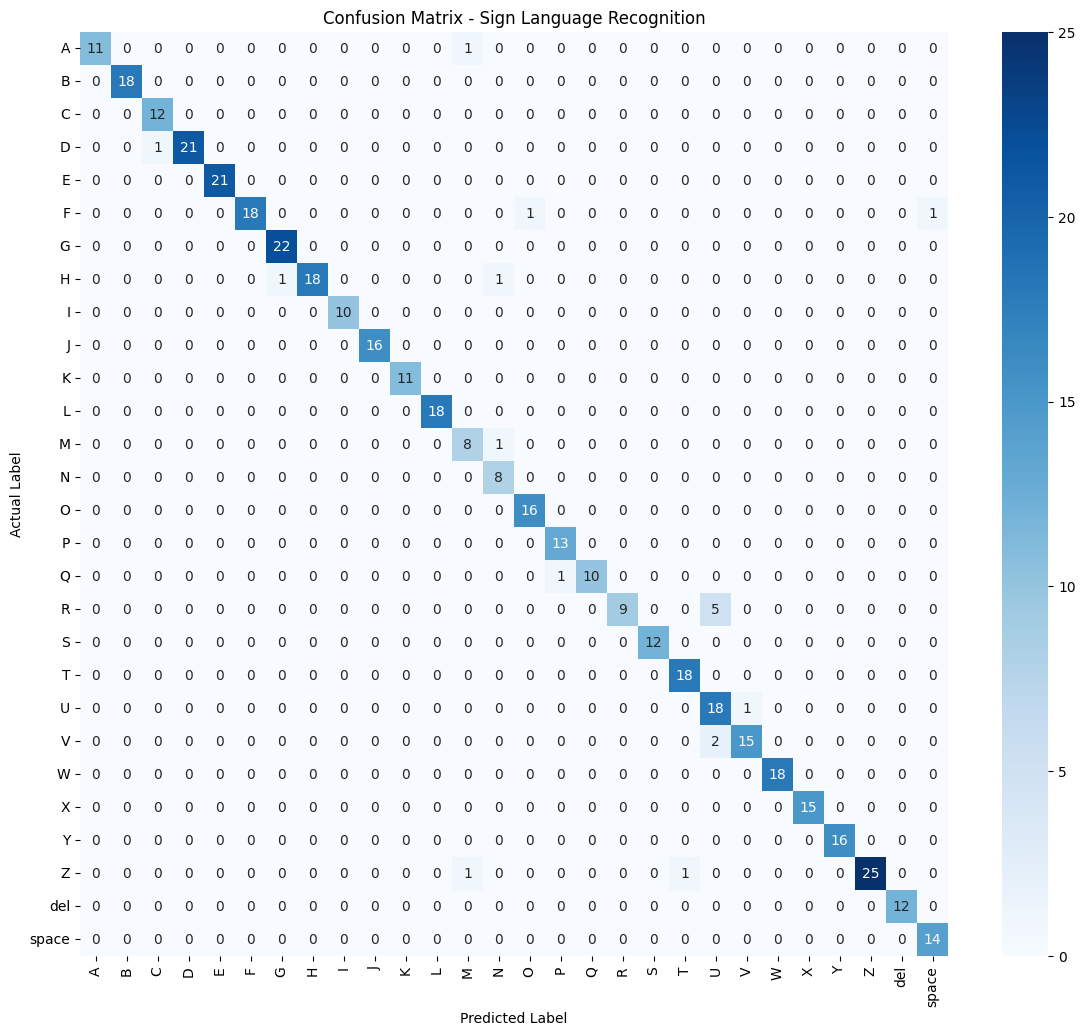

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - Sign Language Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

### ROC-AUC

In [68]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Convert true labels to one-hot/binary format
y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(le.classes_))
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class="ovr",
    average="macro"
)

print("Macro ROC-AUC:", roc_auc)

Macro ROC-AUC: 0.998564466767137


In [69]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Macro ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.959184
1,Macro Precision,0.960270
2,Macro Recall,0.959561
3,Macro F1-Score,0.956847
4,Macro ROC-AUC,0.998564


In [71]:
results["Score (%)"] = results["Score"] * 100

results

,Metric,Score,Score (%)
0,Accuracy,0.959184,95.918367
1,Macro Precision,0.960270,96.026958
2,Macro Recall,0.959561,95.956058
3,Macro F1-Score,0.956847,95.684735
4,Macro ROC-AUC,0.998564,99.856447


In [72]:
final_model.save("sign_language_ann.keras")

In [73]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [75]:
joblib.dump(
    le,
    "label_encoder.pkl"
)

['label_encoder.pkl']